# TT-09 — AdaBoost: Phát hiện xâm nhập mạng (NSL-KDD)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Nạp dữ liệu, gộp nhãn nhị phân

In [2]:
COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty",
]

def load_nsl_kdd(path):
    df = pd.read_csv(path, names=COLUMNS)
    df["y"] = (df["label"] != "normal").astype(int)
    df = df.drop(columns=["label", "difficulty"])
    return df

df_train = load_nsl_kdd("../data/KDDTrain+.txt")
df_test = load_nsl_kdd("../data/KDDTest+.txt")

print("Train shape:", df_train.shape, "| Attack rate:", df_train["y"].mean().round(3))
print("Test shape :", df_test.shape, "| Attack rate:", df_test["y"].mean().round(3))

X_train_raw = df_train.drop(columns=["y"]); y_train = df_train["y"]
X_test_raw = df_test.drop(columns=["y"]); y_test = df_test["y"]

Train shape: (125973, 42) | Attack rate: 0.465
Test shape : (22544, 42) | Attack rate: 0.569


## 2. Tiền xử lý: one-hot + scale

In [3]:
cat_cols = ["protocol_type", "service", "flag"]
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

def make_pipeline(estimator):
    return Pipeline([("prep", preprocess), ("clf", estimator)])

## 3. EDA: phân bố tấn công

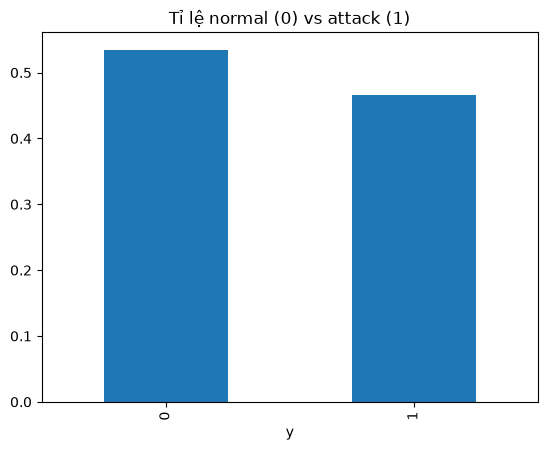

In [4]:
df_train["y"].value_counts(normalize=True).plot(kind="bar", title="Tỉ lệ normal (0) vs attack (1)")
plt.show()

## 4. Baseline: DummyClassifier + 1 stump

In [5]:
dummy = make_pipeline(DummyClassifier(strategy="most_frequent"))
dummy.fit(X_train_raw, y_train)
f1_dummy = f1_score(y_test, dummy.predict(X_test_raw))

single_stump = make_pipeline(DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE))
single_stump.fit(X_train_raw, y_train)
f1_stump = f1_score(y_test, single_stump.predict(X_test_raw))

print(f"Dummy F1 = {f1_dummy:.3f}")
print(f"1 stump F1 = {f1_stump:.3f}")

Dummy F1 = 0.000
1 stump F1 = 0.795


## 5. AdaBoost 300 stump

In [6]:
ada = make_pipeline(AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=300, learning_rate=0.5, random_state=RANDOM_STATE,
))
ada.fit(X_train_raw, y_train)
f1_ada_test = f1_score(y_test, ada.predict(X_test_raw))
print(f"AdaBoost 300 stumps, F1 test gốc = {f1_ada_test:.3f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(ada, X_train_raw, y_train, cv=cv, scoring="f1")
print(f"AdaBoost F1 CV = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

AdaBoost 300 stumps, F1 test gốc = 0.758
AdaBoost F1 CV = 0.984 (+/- 0.001)


## 6. Đường F1 theo n_estimators = 1..300

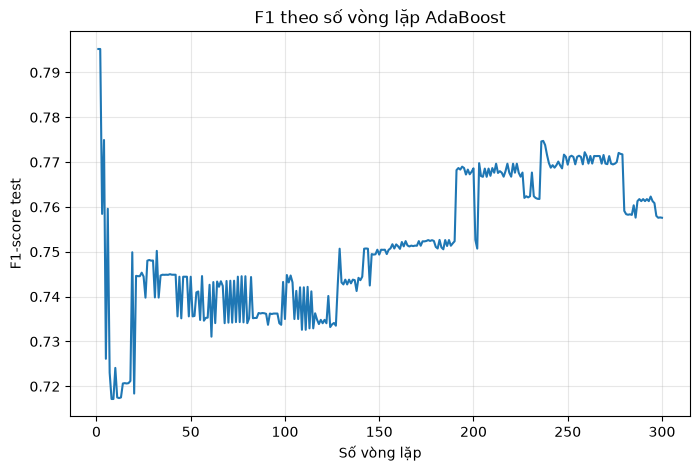

In [7]:
ada_raw = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=300, learning_rate=0.5, random_state=RANDOM_STATE,
)
X_train_enc = preprocess.fit_transform(X_train_raw, y_train)
X_test_enc = preprocess.transform(X_test_raw)
ada_raw.fit(X_train_enc, y_train)

f1_by_round = [f1_score(y_test, pred) for pred in ada_raw.staged_predict(X_test_enc)]

plt.figure(figsize=(8,5))
plt.plot(range(1, 301), f1_by_round)
plt.xlabel("Số vòng lặp"); plt.ylabel("F1-score test")
plt.title("F1 theo số vòng lặp AdaBoost"); plt.grid(alpha=0.3)
plt.savefig("../reports/f1_theo_vong_lap.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Thí nghiệm nhiễu nhãn (5%)

In [8]:
def flip_labels(y, frac, seed=RANDOM_STATE):
    y_noisy = y.copy()
    rng = np.random.RandomState(seed)
    n_flip = int(len(y) * frac)
    idx = rng.choice(y.index, size=n_flip, replace=False)
    y_noisy.loc[idx] = 1 - y_noisy.loc[idx]
    return y_noisy

y_train_noisy = flip_labels(y_train, 0.05)

ada_noisy = make_pipeline(AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=300, learning_rate=0.5, random_state=RANDOM_STATE))
ada_noisy.fit(X_train_raw, y_train_noisy)
f1_ada_noisy = f1_score(y_test, ada_noisy.predict(X_test_raw))

rf_clean = make_pipeline(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
rf_clean.fit(X_train_raw, y_train)
f1_rf_clean = f1_score(y_test, rf_clean.predict(X_test_raw))

rf_noisy = make_pipeline(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
rf_noisy.fit(X_train_raw, y_train_noisy)
f1_rf_noisy = f1_score(y_test, rf_noisy.predict(X_test_raw))

noise_table = pd.DataFrame({
    "Model": ["AdaBoost", "RandomForest"],
    "F1_sach": [f1_ada_test, f1_rf_clean],
    "F1_nhieu_5%": [f1_ada_noisy, f1_rf_noisy],
})
noise_table["Tut_diem"] = noise_table["F1_sach"] - noise_table["F1_nhieu_5%"]
noise_table

,Model,F1_sach,F1_nhieu_5%,Tut_diem
0,AdaBoost,0.75759,0.784714,-0.027125
1,RandomForest,0.76195,0.748711,0.013239


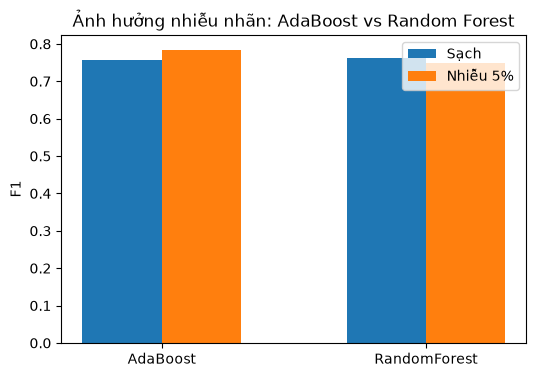

In [9]:
x = np.arange(2)
plt.figure(figsize=(6,4))
plt.bar(x-0.15, noise_table["F1_sach"], width=0.3, label="Sạch")
plt.bar(x+0.15, noise_table["F1_nhieu_5%"], width=0.3, label="Nhiễu 5%")
plt.xticks(x, noise_table["Model"]); plt.ylabel("F1"); plt.legend()
plt.title("Ảnh hưởng nhiễu nhãn: AdaBoost vs Random Forest")
plt.savefig("../reports/thi_nghiem_nhieu.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. So sánh AdaBoost vs Gradient Boosting vs Random Forest

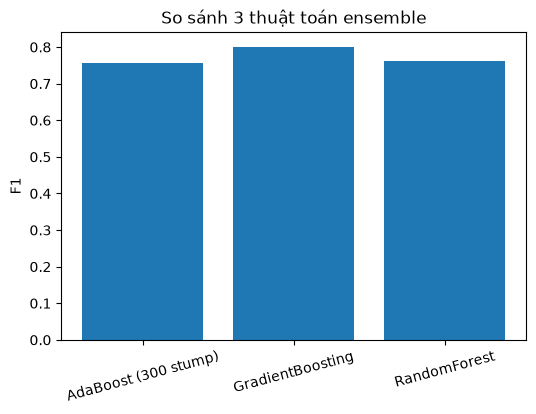

In [10]:
gb = make_pipeline(GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE))
gb.fit(X_train_raw, y_train)
f1_gb = f1_score(y_test, gb.predict(X_test_raw))

compare_table = pd.DataFrame({
    "Model": ["AdaBoost (300 stump)", "GradientBoosting", "RandomForest"],
    "F1_test_goc": [f1_ada_test, f1_gb, f1_rf_clean],
})
compare_table

plt.figure(figsize=(6,4))
plt.bar(compare_table["Model"], compare_table["F1_test_goc"])
plt.ylabel("F1"); plt.xticks(rotation=15)
plt.title("So sánh 3 thuật toán ensemble")
plt.savefig("../reports/so_sanh_ensemble.png", dpi=120, bbox_inches="tight")
plt.show()

## 9–10. Đánh giá test gốc + ma trận nhầm lẫn + báo động giả

In [11]:
y_pred = ada.predict(X_test_raw)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(cm)
print(classification_report(y_test, y_pred, target_names=["normal","attack"]))

packets_per_minute = 100_000  # chỉnh lại theo giả định của bạn
fp_rate = fp / (fp + tn)
false_alarms_per_day = fp_rate * packets_per_minute * 60 * 24
print(f"FPR = {fp_rate:.4%}")
print(f"Ước tính báo động giả/ngày = {false_alarms_per_day:,.0f}")

[[8998  713]
 [4573 8260]]
              precision    recall  f1-score   support

      normal       0.66      0.93      0.77      9711
      attack       0.92      0.64      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.79      0.79      0.77     22544
weighted avg       0.81      0.77      0.76     22544

FPR = 7.3422%
Ước tính báo động giả/ngày = 10,572,753


## Lưu model

In [12]:
joblib.dump(ada, "../models/adaboost.joblib")
print("Đã lưu models/adaboost.joblib")

Đã lưu models/adaboost.joblib
